# Introduction
This colab worksheet provides a starting point for Task 1 (the natural language processing assignment).

In [4]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060 Laptop GPU


# Data Loading

In [5]:
# Download the data stored in a csv file from one of these two locations
# If you're running all your experiments
# on a machine at home rather than using colab, then make sure you save it
# rather than repeatedly downloading it.
#!pip install pandas
import pandas as pd
train_df = pd.read_csv('spam_detection_training_data.csv')
test_df = pd.read_csv('spam_detection_test_data.csv')

# Check the data downloaded correctly
If any of these assertions fail, redownload the data

In [6]:
import hashlib

def confirm_checksum(filename, true_checksum):
    sha1 = hashlib.sha1()
    with open(filename, 'rb') as f:
        while True:
            data = f.read(8192)
            if not data:
                break
            sha1.update(data)
    checksum = sha1.hexdigest()
    assert checksum == true_checksum, f'Checksum does not match for {filename}, redownload the data.'
    print(f"{filename} PASS！")

confirm_checksum('spam_detection_training_data.csv', '807818a04b1f14412767e0929014fe0279047188')
confirm_checksum('spam_detection_test_data.csv', '93556bbad693968096613011355fa490d1fad4d5')

spam_detection_training_data.csv PASS！
spam_detection_test_data.csv PASS！


# Load the data

In [7]:
import pandas as pd

# Load the data using np.load
data = pd.read_csv('spam_detection_training_data.csv')

# Extract the text
text = data['text'].values
# and the labels
labels = data['label'].values

print(text.shape, labels.shape)

test_data = pd.read_csv('spam_detection_test_data.csv')
test_text = test_data['text'].values
print(test_text.shape)

(3619,) (3619,)
(1552,)


# Data Visualisation
Here's an example of how to display the text based on its label.

In [8]:
def print_text(text, label):
  if label == 0:
    print (text, '\nis not spam!')
  else:
    print (text, '\nis spam!')

import numpy as np
idx = np.random.randint(0, text.shape[0])
print_text(text[idx], labels[idx])

Subject: april wellhead production estimate
daren ,
this didn ' t help as i am unable to access any information on the file .
bob
- - - - - - - - - - - - - - - - - - - - - - forwarded by robert cotten / hou / ect on 03 / 21 / 2001 04 : 36
pm - - - - - - - - - - - - - - - - - - - - - - - - - - -
from : vance l taylor / enron @ enronxgate on 03 / 21 / 2001 02 : 42 pm
to : robert cotten / hou / ect @ ect
cc : melissa graves / enron @ enronxgate
subject : april wellhead production estimate
bob ,
please see the attached file calculating an estimate of wellhead production
for the month of april , 2001 . please be advised that this is a preliminary
estimate as i have yet to meet with the gas buyers and i have not received
any customer nominations . our pre - nom meeting is on tomorrow at 3 : 00 p . m .
thanks ,
vlt
x 3 - 6353 
is not spam!


#Data Preprocessing and Model Training


In [9]:
#@title Data preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
html_re  = re.compile(r'<[^>]+>')
url_re   = re.compile(r'\b(?:https?://\S+|www\.\S+|\S+@\S+)\b')
punct_re = re.compile(r"[^\w\s\'\<\>]")
num_re   = re.compile(r'\d+')
space_re = re.compile(r'\s+')

stop_words = set(stopwords.words('english'))
modal_exceptions = {
    'now','then','just','still','even','ever','also',
    'however','though','yet','already','soon'}
lemmatizer = WordNetLemmatizer()
stop_words -= modal_exceptions

def preprocess_text(text):
    text = html_re.sub('', text)
    text = url_re.sub(' <URL> ', text)
    text = num_re.sub(' <NUM> ', text)
    text = punct_re.sub(' ', text)
    text = space_re.sub(' ', text).strip().lower()
    # Split the word
    tokens = [lemmatizer.lemmatize(tok)
    for tok in text.split()
    if tok not in stop_words]
    return ' '.join(tokens)
print_text(text[idx], labels[idx])

Subject: april wellhead production estimate
daren ,
this didn ' t help as i am unable to access any information on the file .
bob
- - - - - - - - - - - - - - - - - - - - - - forwarded by robert cotten / hou / ect on 03 / 21 / 2001 04 : 36
pm - - - - - - - - - - - - - - - - - - - - - - - - - - -
from : vance l taylor / enron @ enronxgate on 03 / 21 / 2001 02 : 42 pm
to : robert cotten / hou / ect @ ect
cc : melissa graves / enron @ enronxgate
subject : april wellhead production estimate
bob ,
please see the attached file calculating an estimate of wellhead production
for the month of april , 2001 . please be advised that this is a preliminary
estimate as i have yet to meet with the gas buyers and i have not received
any customer nominations . our pre - nom meeting is on tomorrow at 3 : 00 p . m .
thanks ,
vlt
x 3 - 6353 
is not spam!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Behram\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Behram\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Behram\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Error analysis function for classification errors
def error_analysis(X_val, y_val, y_pred, texts_original=None):
    """
    Analyze misclassified samples in a classification task.

    Parameters:
    - X_val: list or array of preprocessed validation texts
    - y_val: true labels for validation set
    - y_pred: predicted labels for validation set
    - texts_original: optional list of original texts (if X_val is preprocessed)
    
    Returns:
    - errors: list of all misclassified sample info
    - false_positives: list of false positive sample info
    - false_negatives: list of false negative sample info
    """
    # Identify error samples
    errors = []
    for i, (true, pred) in enumerate(zip(y_val, y_pred)):
        if true != pred:
            errors.append({
                'index': i,
                'text': texts_original[i] if texts_original is not None else X_val[i],
                'true': true,
                'pred': pred
            })
    
    # Compute confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Separate false positives (ham predicted as spam) and false negatives (spam predicted as ham)
    false_positives = [e for e in errors if e['true'] == 0 and e['pred'] == 1]
    false_negatives = [e for e in errors if e['true'] == 1 and e['pred'] == 0]
    
    # Print summary statistics
    total = len(y_val)
    num_errors = len(errors)
    print(f"Total errors: {num_errors}/{total} ({num_errors/total*100:.2f}%)")
    print(f"False positives (ham → spam): {len(false_positives)}/{num_errors} ({len(false_positives)/num_errors*100:.2f}%)")
    print(f"False negatives (spam → ham): {len(false_negatives)}/{num_errors} ({len(false_negatives)/num_errors*100:.2f}%)")
    
    # 2. Text length analysis
    correct_lens = [len(X_val[i]) for i in range(total) if y_val[i] == y_pred[i]]
    error_lens = [len(e['text']) for e in errors]
    
    # Plot text length distributions for correct vs. error samples
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(correct_lens, kde=True, color='green', label='Correct')
    sns.histplot(error_lens, kde=True, color='red', label='Errors')
    plt.xlabel('Text Length')
    plt.ylabel('Count')
    plt.title('Distribution of Text Lengths: Correct vs. Error')
    plt.legend()
    
    # 3. Plot confusion matrix
    plt.subplot(1, 2, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    # 4. Word frequency analysis in error samples
    def extract_words(text):
        return re.findall(r'\b\w+\b', text.lower())
    
    fp_words = []
    for e in false_positives:
        fp_words.extend(extract_words(e['text']))
    
    fn_words = []
    for e in false_negatives:
        fn_words.extend(extract_words(e['text']))
    
    fp_common = Counter(fp_words).most_common(15)
    fn_common = Counter(fn_words).most_common(15)
    
    # Plot common words for false positives and false negatives
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    words_fp, counts_fp = zip(*fp_common) if fp_common else ([], [])
    plt.barh(words_fp, counts_fp)
    plt.xlabel('Frequency')
    plt.title('Top Words in False Positives')
    
    plt.subplot(1, 2, 2)
    words_fn, counts_fn = zip(*fn_common) if fn_common else ([], [])
    plt.barh(words_fn, counts_fn)
    plt.xlabel('Frequency')
    plt.title('Top Words in False Negatives')
    
    plt.tight_layout()
    plt.show()
    
    # 5. Display example error samples
    print("\n===== Example False Positives (Ham → Spam) =====")
    for i, e in enumerate(false_positives[:3]):
        snippet = e['text'][:300] + "..." if len(e['text']) > 300 else e['text']
        print(f"\nSample {i+1} (index {e['index']}):\n{snippet}")
    
    print("\n===== Example False Negatives (Spam → Ham) =====")
    for i, e in enumerate(false_negatives[:3]):
        snippet = e['text'][:300] + "..." if len(e['text']) > 300 else e['text']
        print(f"\nSample {i+1} (index {e['index']}):\n{snippet}")
    
    # Return the lists for further analysis if needed
    return errors, false_positives, false_negatives

# Example usage:
# errors, false_positives, false_negatives = error_analysis(
#     X_val, y_val, y_val_pred, texts_original=X_val  # or pass original texts
# )



=== Loading Data ===
Data loading took 0.05 seconds

=== Feature Extraction ===
Memory usage: 667.57 MB
Loading cached SBERT features...
SBERT feature extraction took 0.02 seconds
Memory usage: 682.74 MB

Extracting TF-IDF features...
TF-IDF feature extraction took 1.22 seconds
Memory usage: 714.22 MB

=== Training All Models ===

Training TF-IDF only model...

=== Training TF-IDF Only ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best parameters for TF-IDF Only: {'C': 10.0, 'class_weight': 'balanced', 'penalty': 'l2'}

TF-IDF Only Validation Results:
Accuracy: 0.9848066298342542

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       510
           1       0.96      0.99      0.97       214

    accuracy                           0.98       724
   macro avg       0.98      0.99      0.98       724
weighted avg       0.99      0.98      0.98       724

TF-IDF Only training and evaluation took 1

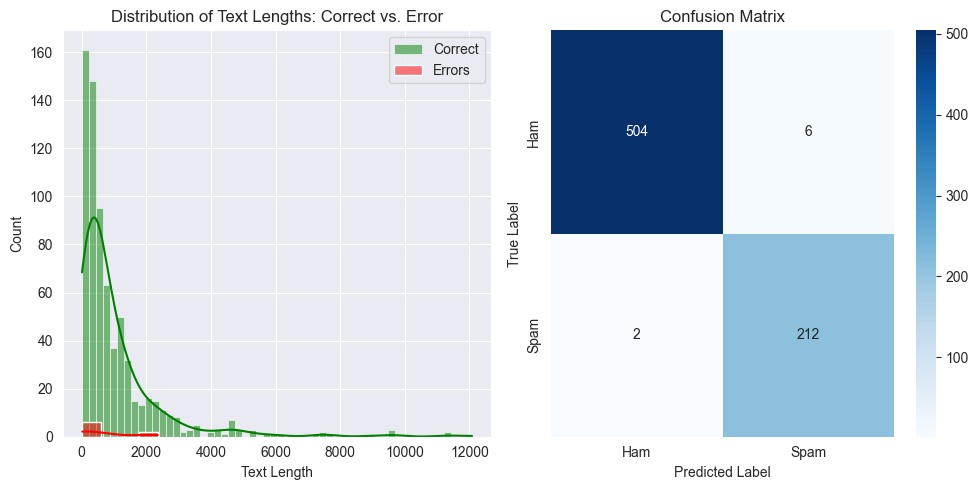

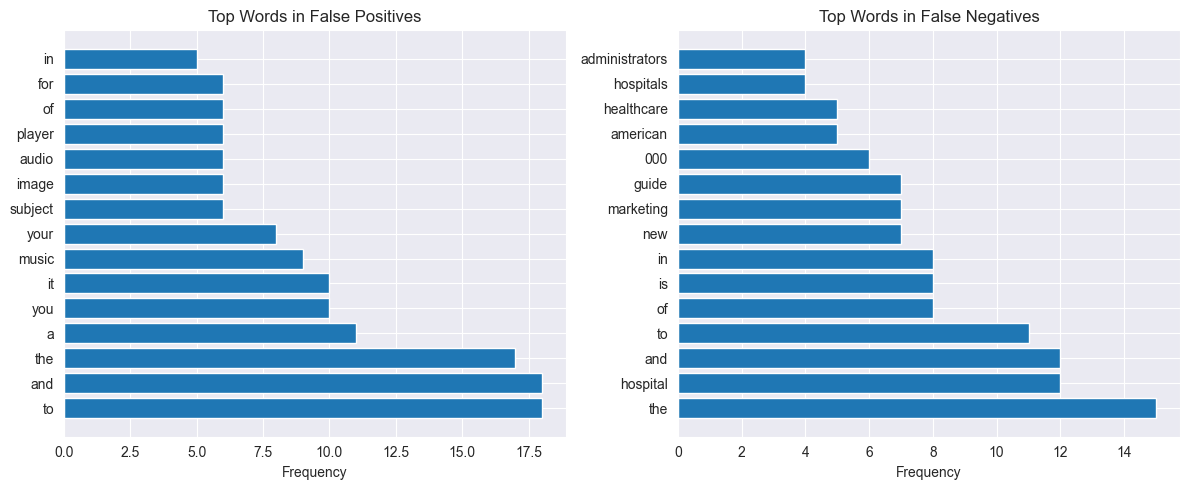


===== Example False Positives (Ham → Spam) =====

Sample 1 (index 287):
Subject: revised


Sample 2 (index 309):
Subject: welcome to the next wave in digital music
if you have trouble viewing this page , please click here . to unsubscribe ,
please click here .
[ image ]
now , you can have your music your way  * online and off . plus , get a $ 50 rebate
by mail .
music online has always played by online ...

Sample 3 (index 350):
Subject: first delivery atmic marquis
see attached letter

===== Example False Negatives (Spam → Ham) =====

Sample 1 (index 571):
Subject: i promised to help 5000 people
please refer all questions , opinions or additional feedback to :
service dept
9420 reseda blvd # 133
northridge , ca 91324


Sample 2 (index 579):
Subject: cardiology , radiology , 7 , 000 senior hospitals , , 172 , 000 senior hospital administrators and doctors .
7 , 000 hospitals , 172 , 000 senior hospital administrators .
pre _ publication offer of $ 247 . 00 ( reg . $ 1 , 299 ) .
the n

In [11]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack
import numpy as np
import os
import time
import psutil
from datetime import datetime

def print_memory_usage():
    process = psutil.Process()
    print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")

def log_time(start_time, step_name):
    elapsed = time.time() - start_time
    print(f"{step_name} took {elapsed:.2f} seconds")
    return time.time()

# 1. Load data
print("\n=== Loading Data ===")
start_time = time.time()

train_df = pd.read_csv('spam_detection_training_data.csv')
texts = train_df['text'].tolist()
labels = train_df['label'].values

test_df = pd.read_csv('spam_detection_test_data.csv')
test_texts = test_df['text'].tolist()

start_time = log_time(start_time, "Data loading")

# 2. Split into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# 3. Feature extraction
print("\n=== Feature Extraction ===")
print_memory_usage()

# SBERT features
sbert_features_path = {
    'train': 'sbert_features_train.npy',
    'val': 'sbert_features_val.npy',
    'test': 'sbert_features_test.npy'
}

if all(os.path.exists(path) for path in sbert_features_path.values()):
    print("Loading cached SBERT features...")
    sbert_train = np.load(sbert_features_path['train'])
    sbert_val   = np.load(sbert_features_path['val'])
    sbert_test  = np.load(sbert_features_path['test'])
else:
    print("Extracting SBERT features...")
    model = SentenceTransformer('all-mpnet-base-v2', device='cuda')
    sbert_train = model.encode(X_train, batch_size=64, show_progress_bar=True)
    sbert_val   = model.encode(X_val, batch_size=64, show_progress_bar=True)
    sbert_test  = model.encode(test_texts, batch_size=64, show_progress_bar=True)
    # Cache features
    np.save(sbert_features_path['train'], sbert_train)
    np.save(sbert_features_path['val'],   sbert_val)
    np.save(sbert_features_path['test'],  sbert_test)

start_time = log_time(start_time, "SBERT feature extraction")
print_memory_usage()

# TF-IDF features
print("\nExtracting TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=3
)
tfidf_train = tfidf.fit_transform(X_train)
tfidf_val   = tfidf.transform(X_val)
tfidf_test  = tfidf.transform(test_texts)

start_time = log_time(start_time, "TF-IDF feature extraction")
print_memory_usage()

# 4. Model training and evaluation
def train_and_evaluate_model(X_train, X_val, y_train, y_val, model_name):
    print(f"\n=== Training {model_name} ===")
    start_time = time.time()
    
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0],
        'class_weight': ['balanced'],
        'penalty': ['l2'],
    }
    
    clf = GridSearchCV(
        LogisticRegression(solver='liblinear', max_iter=1000, random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=2,
        verbose=1
    )
    
    clf.fit(X_train, y_train)
    
    print(f"\nBest parameters for {model_name}: {clf.best_params_}")
    y_val_pred = clf.predict(X_val)
    
    print(f"\n{model_name} Validation Results:")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))
    
    log_time(start_time, f"{model_name} training and evaluation")
    return clf, y_val_pred

# 5. Train three models
print("\n=== Training All Models ===")

# Model 1: TF-IDF only
print("\nTraining TF-IDF only model...")
tfidf_model, tfidf_y_val_pred = train_and_evaluate_model(
    tfidf_train, tfidf_val,
    y_train, y_val,
    "TF-IDF Only"
)

# Model 2: SBERT only
print("\nTraining SBERT only model...")
sbert_model, sbert_y_val_pred = train_and_evaluate_model(
    sbert_train, sbert_val,
    y_train, y_val,
    "SBERT Only"
)

# Model 3: Combined TF-IDF + SBERT
print("\nTraining Combined model...")
X_train_combined = hstack([tfidf_train, sbert_train])
X_val_combined   = hstack([tfidf_val,   sbert_val])
combined_model, y_val_pred = train_and_evaluate_model(
    X_train_combined, X_val_combined,
    y_train, y_val,
    "TF-IDF + SBERT"
)


# 6. Generate test set predictions
print("\n=== Generating Test Predictions ===")

models = {
    'tfidf':   (tfidf_model, tfidf_test),
    'sbert':   (sbert_model, sbert_test),
    'combined': (combined_model, hstack([tfidf_test, sbert_test]))
}

for model_name, (model, X_test) in models.items():
    predictions = model.predict(X_test)
    filename = f'results_{model_name}_{datetime.now().strftime("%Y%m%d_%H%M")}.csv'
    np.savetxt(filename, predictions, delimiter=',', fmt='%d')
    print(f"Saved predictions for {model_name} model to {filename}")

print("\n=== Experiment Completed ===")
print_memory_usage()
# Run error analysis
errors, false_positives, false_negatives = error_analysis(
    X_val, y_val, y_val_pred, texts_original=X_val
)

# Analyze causes of misclassification
print("\n===== Error Analysis Summary =====")

# 1. Misclassification trend
print("1. Common Misclassification Pattern:")
if len(false_positives) > len(false_negatives):
    print("   - The model tends to classify legitimate emails as spam (more false positives).")
else:
    print("   - The model tends to classify spam emails as legitimate (more false negatives).")

# 2. Average text length statistics
fp_avg_len = sum(len(e['text']) for e in false_positives) / max(1, len(false_positives))
fn_avg_len = sum(len(e['text']) for e in false_negatives) / max(1, len(false_negatives))
correct_avg_len = sum(len(X_val[i]) for i in range(len(X_val)) if y_val[i] == y_val_pred[i]) / max(1, sum(y_val == y_val_pred))

print("\n2. Text Length Characteristics:")
print(f"   - Average length of correctly classified samples: {correct_avg_len:.1f} characters")
print(f"   - Average length of false positives: {fp_avg_len:.1f} characters")
print(f"   - Average length of false negatives: {fn_avg_len:.1f} characters")

# 3. Suggestions for improvement
print("\n3. Suggestions for Improvement:")
if fp_avg_len < correct_avg_len:
    print("   - Short ham messages are more likely to be misclassified as spam. Consider augmenting with more short ham samples.")
if fn_avg_len > correct_avg_len:
    print("   - Long spam messages are more likely to be missed. Consider including more long spam samples.")
print("   - Consider extracting richer semantic features, such as named entities or topic models.")
print("   - Try more powerful pre-trained models, such as BERT-Large or RoBERTa.")

Total errors: 8/724 (1.10%)
False positives (ham → spam): 6/8 (75.00%)
False negatives (spam → ham): 2/8 (25.00%)


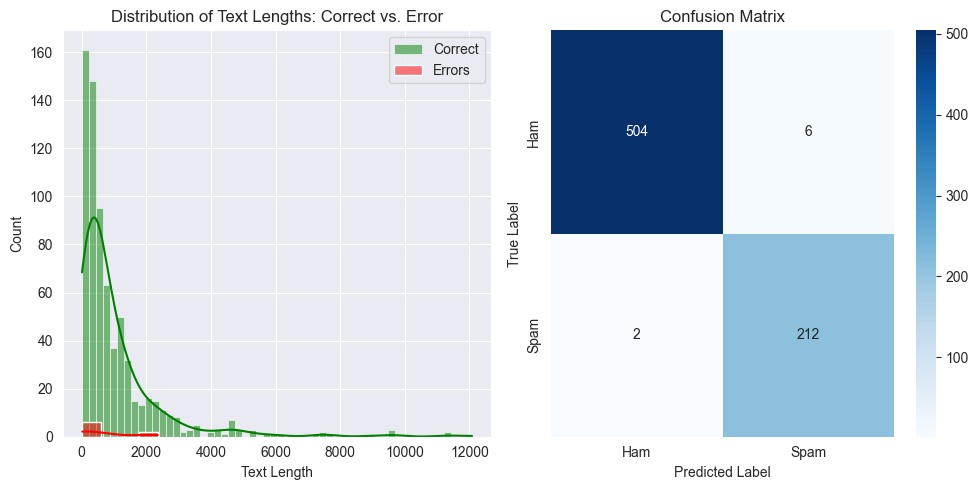

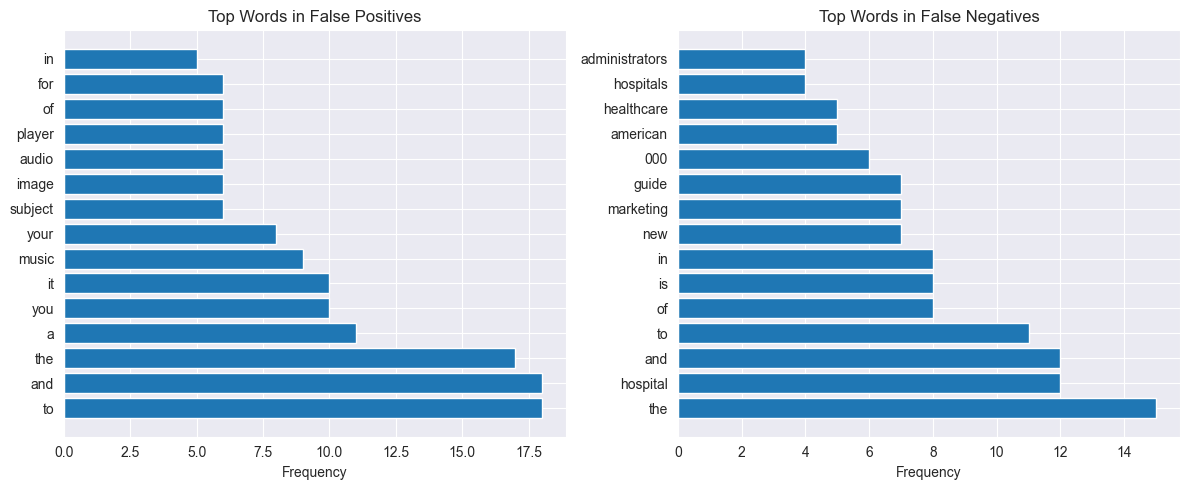


===== Example False Positives (Ham → Spam) =====

Sample 1 (index 287):
Subject: revised


Sample 2 (index 309):
Subject: welcome to the next wave in digital music
if you have trouble viewing this page , please click here . to unsubscribe ,
please click here .
[ image ]
now , you can have your music your way  * online and off . plus , get a $ 50 rebate
by mail .
music online has always played by online ...

Sample 3 (index 350):
Subject: first delivery atmic marquis
see attached letter

===== Example False Negatives (Spam → Ham) =====

Sample 1 (index 571):
Subject: i promised to help 5000 people
please refer all questions , opinions or additional feedback to :
service dept
9420 reseda blvd # 133
northridge , ca 91324


Sample 2 (index 579):
Subject: cardiology , radiology , 7 , 000 senior hospitals , , 172 , 000 senior hospital administrators and doctors .
7 , 000 hospitals , 172 , 000 senior hospital administrators .
pre _ publication offer of $ 247 . 00 ( reg . $ 1 , 299 ) .
the n

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Run error analysis
errors, false_positives, false_negatives = error_analysis(
    X_val, y_val, y_val_pred, texts_original=X_val
)

# Analyze causes of misclassification
print("\n===== Error Analysis Summary =====")

# 1. Misclassification trend
print("1. Common Misclassification Pattern:")
if len(false_positives) > len(false_negatives):
    print("   - The model tends to classify legitimate emails as spam (more false positives).")
else:
    print("   - The model tends to classify spam emails as legitimate (more false negatives).")

# 2. Average text length statistics
fp_avg_len = sum(len(e['text']) for e in false_positives) / max(1, len(false_positives))
fn_avg_len = sum(len(e['text']) for e in false_negatives) / max(1, len(false_negatives))
correct_avg_len = sum(len(X_val[i]) for i in range(len(X_val)) if y_val[i] == y_val_pred[i]) / max(1, sum(y_val == y_val_pred))

print("\n2. Text Length Characteristics:")
print(f"   - Average length of correctly classified samples: {correct_avg_len:.1f} characters")
print(f"   - Average length of false positives: {fp_avg_len:.1f} characters")
print(f"   - Average length of false negatives: {fn_avg_len:.1f} characters")

# 3. Suggestions for improvement
print("\n3. Suggestions for Improvement:")
if fp_avg_len < correct_avg_len:
    print("   - Short ham messages are more likely to be misclassified as spam. Consider augmenting with more short ham samples.")
if fn_avg_len > correct_avg_len:
    print("   - Long spam messages are more likely to be missed. Consider including more long spam samples.")
print("   - Consider extracting richer semantic features, such as named entities or topic models.")
print("   - Try more powerful pre-trained models, such as BERT-Large or RoBERTa.")


#Assessment and analysis

In [13]:
#@title Automation of Text Categorization
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, train_test_split

# Split the data
x_train, x_val, y_train, y_val = train_test_split(
    text, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Build the pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svc', LinearSVC(max_iter=5000, random_state=42))
])

# Parameter grid (note the step prefix)
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__class_weight': [None, 'balanced'],
}

# Perform GridSearch using the pipeline
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search on the training data
grid_search.fit(x_train, y_train)


Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('svc',
                                        LinearSVC(max_iter=5000,
                                                  random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10],
                         'svc__class_weight': [None, 'balanced']},
             scoring='f1', verbose=2)


======= Model Comparison =======

=== Evaluating Model: TF-IDF ===


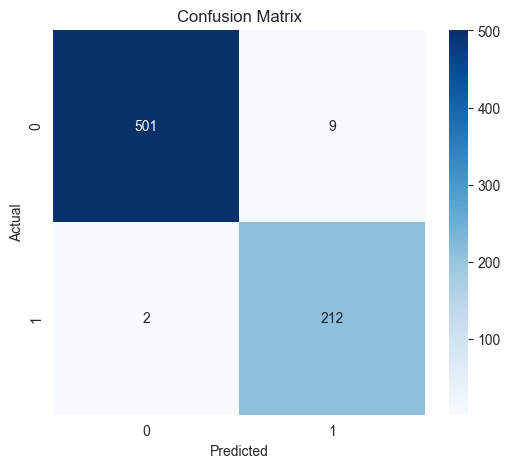

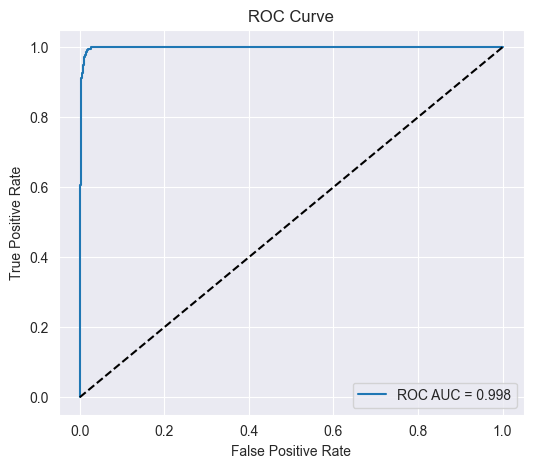

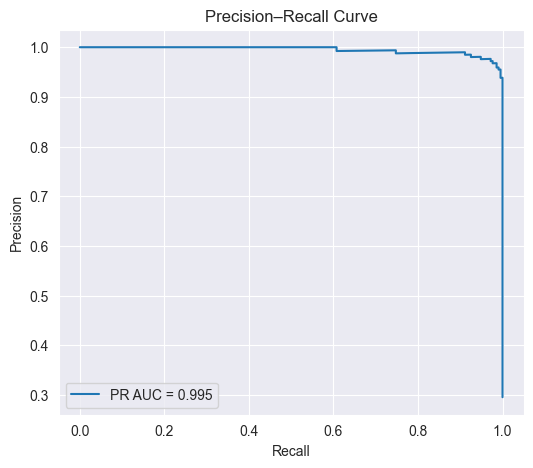

TF-IDF Evaluation Summary:
Accuracy: 0.9848
F1 Score: 0.9849
ROC-AUC: 0.9981

=== Evaluating Model: SBERT ===


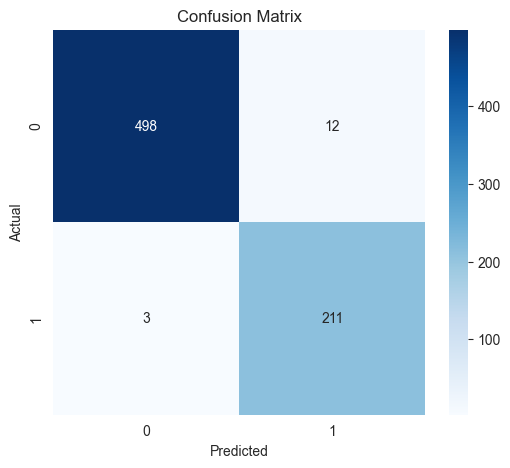

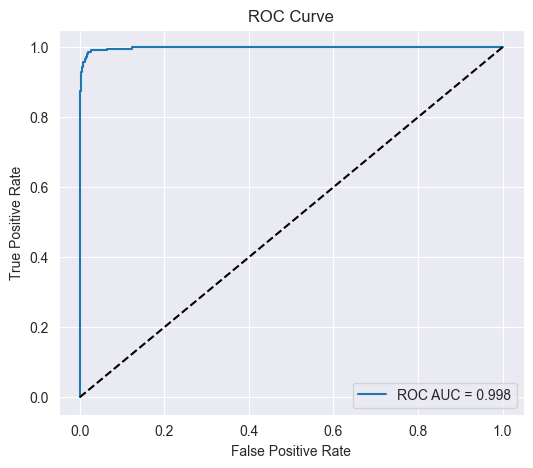

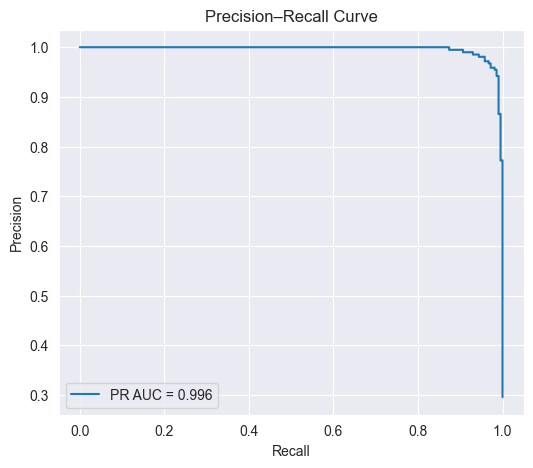

SBERT Evaluation Summary:
Accuracy: 0.9793
F1 Score: 0.9794
ROC-AUC: 0.9982

=== Evaluating Model: Combined ===


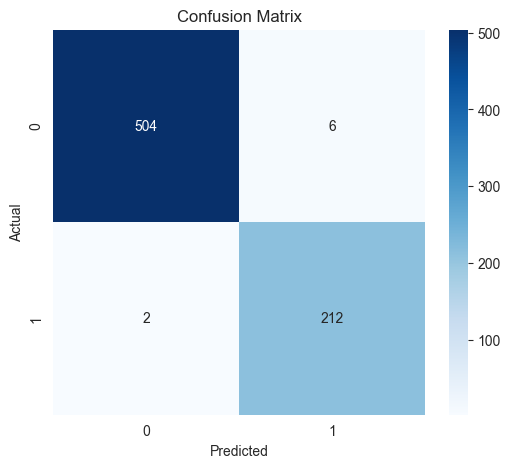

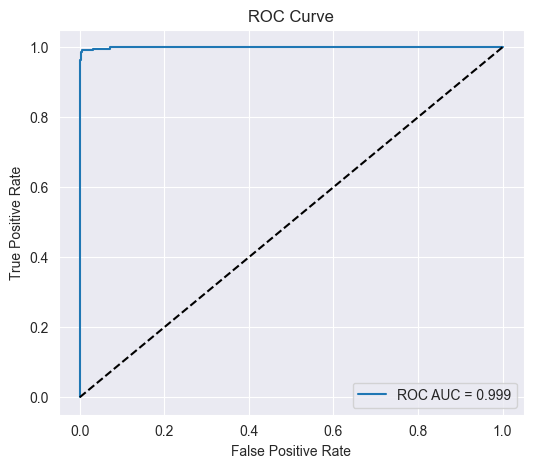

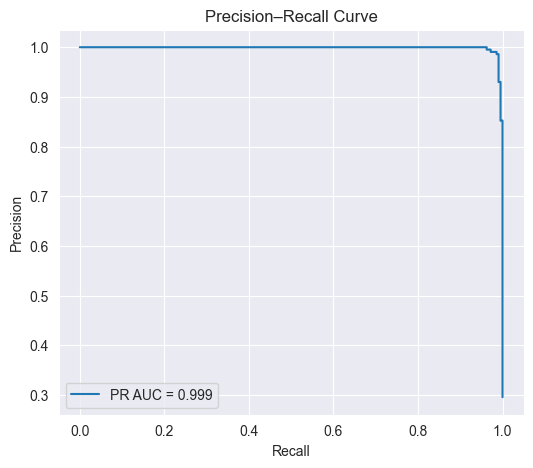

Combined Evaluation Summary:
Accuracy: 0.9890
F1 Score: 0.9890
ROC-AUC: 0.9994


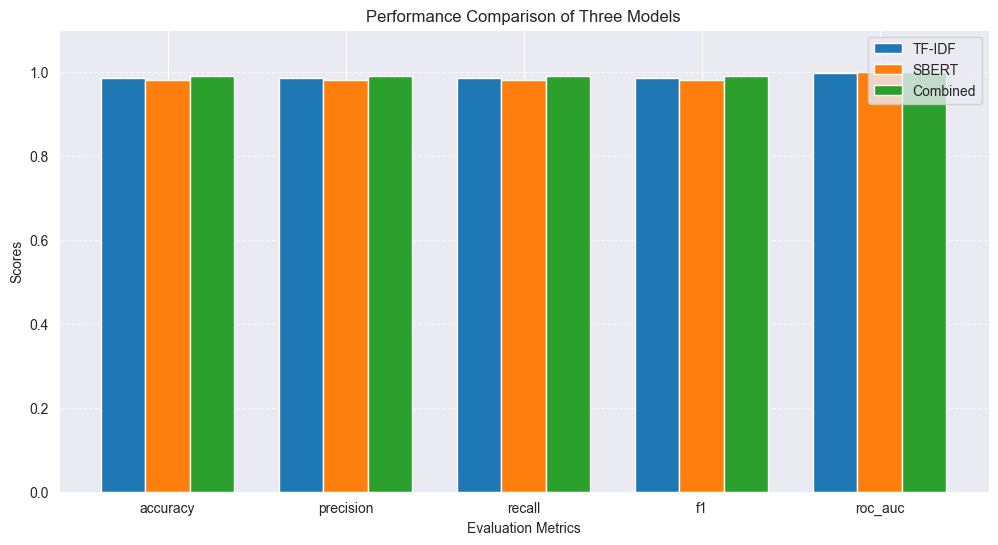


Performance differences compared to TF-IDF baseline:

SBERT vs TF-IDF:
accuracy: -0.0055 (-0.56%)
precision: -0.0053 (-0.54%)
recall: -0.0055 (-0.56%)
f1: -0.0055 (-0.56%)
roc_auc: 0.0001 (+0.01%)

Combined vs TF-IDF:
accuracy: 0.0041 (+0.42%)
precision: 0.0039 (+0.40%)
recall: 0.0041 (+0.42%)
f1: 0.0041 (+0.42%)
roc_auc: 0.0013 (+0.13%)

======= Generating Test Predictions =======
Test predictions saved to results_tfidf_20250515_1123.csv
Test predictions saved to results_sbert_20250515_1123.csv
Test predictions saved to results_combined_20250515_1123.csv

======= All Done! =======


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    classification_report, roc_auc_score
)

# ====== 1. Validation Set Evaluation Function ======
def evaluate_model(
    model, X_test, y_test, class_names=None, save_fig=False, fig_dir='figs', prefix='eval'
):
    y_pred = model.predict(X_test)
    n_classes = len(np.unique(y_test))
    if class_names is None:
        class_names = [str(i) for i in range(n_classes)]

    # Probability output
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        if n_classes == 2:
            # Normalize scores to [0,1]
            y_prob = (scores - scores.min()) / (scores.max() - scores.min())
            y_prob = np.vstack([1 - y_prob, y_prob]).T
        else:
            # Multiclass normalization
            y_prob = (scores - scores.min(axis=0)) / (scores.max(axis=0) - scores.min(axis=0) + 1e-8)
    else:
        raise ValueError("Model must support predict_proba or decision_function.")

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='weighted')
    rec   = recall_score(y_test, y_pred, average='weighted')
    f1    = f1_score(y_test, y_pred, average='weighted')
    cm    = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)

    # Plot Confusion Matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    if save_fig:
        os.makedirs(fig_dir, exist_ok=True)
        plt.savefig(os.path.join(fig_dir, f'{prefix}_confusion_matrix.png'))
    plt.show()

    # ROC Curve and AUC
    if n_classes == 2:
        y_score = y_prob[:, 1] if y_prob.ndim == 2 else y_prob
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        if save_fig:
            plt.savefig(os.path.join(fig_dir, f'{prefix}_roc_curve.png'))
        plt.show()
    else:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        print(f"Multiclass ROC AUC (OvR, weighted): {roc_auc:.3f}")

    # Precision-Recall Curve and AUC
    if n_classes == 2:
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        pr_auc = auc(recall, precision)
        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision–Recall Curve')
        plt.legend()
        if save_fig:
            plt.savefig(os.path.join(fig_dir, f'{prefix}_pr_curve.png'))
        plt.show()
    else:
        pr_auc = None

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'conf_matrix': cm,
        'classification_report': report_dict
    }

# ====== 2. Validation Set Evaluation and Visualization ======
print("\n======= Model Comparison =======")

# Define models and their validation features
models = {
    'TF-IDF': (tfidf_model, tfidf_val),
    'SBERT': (sbert_model, sbert_val),
    'Combined': (combined_model, X_val_combined)
}

all_results = {}

# Evaluate each model
for name, (model, X_eval) in models.items():
    print(f"\n=== Evaluating Model: {name} ===")
    results = evaluate_model(
        model=model,
        X_test=X_eval,
        y_test=y_val,
        prefix=name.lower()
    )
    all_results[name] = results
    print(f"{name} Evaluation Summary:")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"F1 Score: {results['f1']:.4f}")
    print(f"ROC-AUC: {results['roc_auc']:.4f}")

# Visualization of comparisons
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
plt.figure(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.25

for i, (name, result) in enumerate(all_results.items()):
    values = [result[m] for m in metrics]
    plt.bar(x + i*width, values, width, label=name)

plt.xlabel('Evaluation Metrics')
plt.ylabel('Scores')
plt.title('Performance Comparison of Three Models')
plt.xticks(x + width, metrics)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('model_comparison.png')
plt.show()

# Compare performance differences
print("\nPerformance differences compared to TF-IDF baseline:")
baseline = all_results['TF-IDF']
for name, result in all_results.items():
    if name == 'TF-IDF':
        continue
    print(f"\n{name} vs TF-IDF:")
    for metric in metrics:
        diff = result[metric] - baseline[metric]
        pct = diff / baseline[metric] * 100
        print(f"{metric}: {diff:.4f} ({pct:+.2f}%)")

# ====== 3. Test Set Predictions and Saving ======
print("\n======= Generating Test Predictions =======")

# Define models and features for test set
from scipy.sparse import hstack
test_models = {
    'tfidf': (tfidf_model, tfidf_test),
    'sbert': (sbert_model, sbert_test),
    'combined': (combined_model, hstack([tfidf_test, sbert_test]))
}

# Generate predictions and save
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
for name, (model, X_test) in test_models.items():
    test_pred = model.predict(X_test)
    filename = f'results_{name}_{timestamp}.csv'
    np.savetxt(filename, test_pred, delimiter=',', fmt='%d')
    print(f"Test predictions saved to {filename}")

print("\n======= All Done! =======")


# Calculating Confusion Matrix and exporting results

In [26]:
import numpy as np

np.savetxt('results_scientific.csv', test_pred, delimiter=',', fmt='%e')

In [16]:
from sklearn.metrics import confusion_matrix

def confusion_matrix(true_label, pred_label):
  """
  Calculate the confusion matrix for your predicted labels. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
  :param pred_label: Array of predicted labels
  :param true_label: Array of corresponding ground truth (test) labels
  :return: Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.
  """
  return confusion_matrix(true_label, pred_label)


In [17]:

import os
print(os.getcwd())
def save_as_csv(pred_labels, location = '.'):
    """
    Save the labels out as a .csv file
    :pred_labels: numpy array of shape (no_test_labels,) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert pred_labels.shape[0]==1552, 'wrong number of labels, should be 1552 test labels'
    save_as_csv(pred_labels, location=r'E:\Year 2\ml')



E:\Year 2\ml\AML\邮件分类\Spam Detection
